## Presentado por:

## Esteban Garcia Otalvaro
## Fabián Andrés Posso

In [1]:
import pandas as pd
from pathlib import Path

# Nota el doble 'ECGDataDenoised\ECGDataDenoised' al final de la ruta
ruta_carpeta = Path(r"C:\Users\12345\Downloads\ECGDataDenoised\ECGDataDenoised")

todos_los_csvs = list(ruta_carpeta.glob("*.csv"))
print(f"Total de archivos .csv encontrados: {len(todos_los_csvs)}")

nombres_pacientes = []
senales_ii = []

for archivo_csv in todos_los_csvs:
    try:
        # header=None porque no tienen nombres de columnas en la primera fila
        df = pd.read_csv(archivo_csv, header=None)
        
        # Extraer la Derivación II (columna de índice 1)
        senal = df.iloc[:, 1].values
        
        nombres_pacientes.append(archivo_csv.stem)
        senales_ii.append(senal)
    except Exception as e:
        print(f"Error en {archivo_csv.name}: {e}")

print(f"Total de señales de Derivación II cargadas: {len(senales_ii)}")

Total de archivos .csv encontrados: 10646
Total de señales de Derivación II cargadas: 10646


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

archivos = sorted(
    ruta_carpeta.glob("*.csv")
)

senales = []
nombres = []

for archivo in archivos:

    try:

        df = pd.read_csv(
            archivo,
            header=None
        )

        # Derivación II
        señal = df.iloc[:, 1].values

        senales.append(señal)

        nombres.append(
            archivo.stem
        )

    except Exception as e:

        print(
            f"Error en {archivo.name}: {e}"
        )

print(
    "Registros cargados:",
    len(senales)
)

Registros cargados: 10646


In [6]:
primer_archivo = archivos[0]

df_prueba = pd.read_csv(
    primer_archivo,
    header=None
)

print(
    "Archivo:",
    primer_archivo.name
)

print(
    "Número de filas:",
    df_prueba.shape[0]
)

print(
    "Número de columnas:",
    df_prueba.shape[1]
)

Archivo: MUSE_20180111_155115_19000.csv
Número de filas: 5000
Número de columnas: 12


In [8]:
print(
    df_prueba.head()
)

       0       1        2       3       4       5       6       7       8   \
0 -165.33 -358.97 -121.710  270.25 -28.869 -231.16  448.39  636.52  618.45   
1 -150.75 -336.81 -114.980  251.41 -23.883 -217.52  441.74  646.47  642.56   
2 -136.69 -315.56 -108.630  233.45 -19.126 -204.36  436.06  656.31  665.95   
3 -123.74 -296.23 -103.090  217.23 -14.815 -192.29  432.27  666.14  688.05   
4 -112.57 -279.75  -98.611  203.53 -11.213 -181.87  431.08  676.31  708.47   

         9       10      11  
0   -7.8987 -315.16 -570.84  
1   35.3890 -269.51 -532.21  
2   76.5720 -225.83 -495.39  
3  113.5100 -186.00 -461.84  
4  144.3000 -151.68 -432.56  


In [9]:
Fs = 500

N = len(senales[0])

duracion = N / Fs

print(
    "Frecuencia de muestreo:",
    Fs,
    "Hz"
)

print(
    "Número de muestras:",
    N
)

print(
    "Duración:",
    duracion,
    "segundos"
)

Frecuencia de muestreo: 500 Hz
Número de muestras: 5000
Duración: 10.0 segundos


In [10]:
tiempo = np.arange(
    N
) / Fs

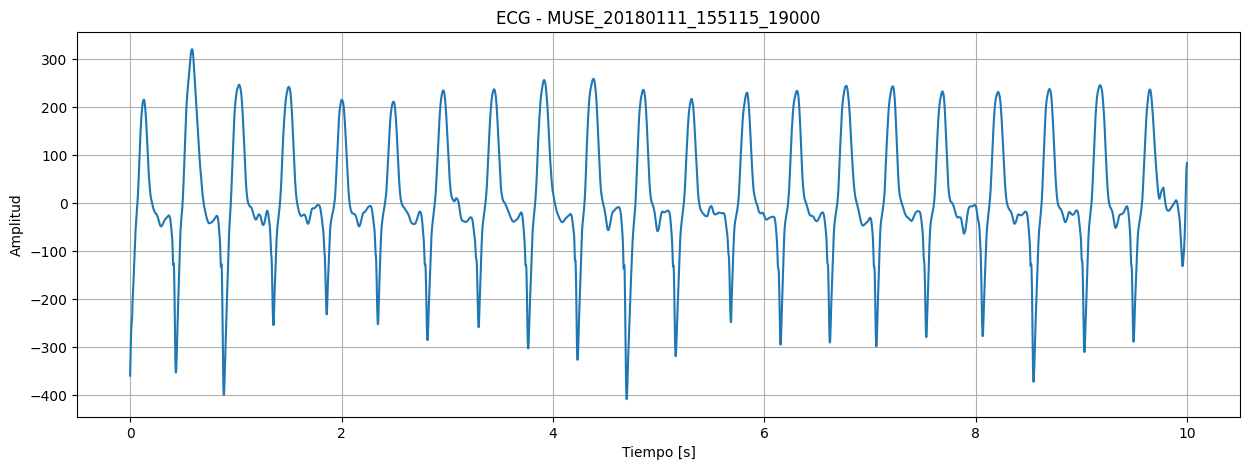

In [11]:
import matplotlib.pyplot as plt

senal_1 = senales[0]

tiempo_1 = np.arange(
    len(senal_1)
) / Fs

plt.figure(figsize=(15,5))

plt.plot(
    tiempo_1,
    senal_1
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.title(
    f"ECG - {nombres[0]}"
)

plt.grid()

plt.show()

In [12]:
for archivo in archivos[:30]:
    print(archivo.name)

MUSE_20180111_155115_19000.csv
MUSE_20180111_155154_74000.csv
MUSE_20180111_155203_15000.csv
MUSE_20180111_155249_70000.csv
MUSE_20180111_155542_84000.csv
MUSE_20180111_155543_90000.csv
MUSE_20180111_155633_99000.csv
MUSE_20180111_155709_17000.csv
MUSE_20180111_155710_23000.csv
MUSE_20180111_155758_17000.csv
MUSE_20180111_155839_67000.csv
MUSE_20180111_155859_36000.csv
MUSE_20180111_155903_57000.csv
MUSE_20180111_155907_78000.csv
MUSE_20180111_155945_02000.csv
MUSE_20180111_160033_11000.csv
MUSE_20180111_160037_37000.csv
MUSE_20180111_160052_85000.csv
MUSE_20180111_160053_89000.csv
MUSE_20180111_160110_47000.csv
MUSE_20180111_160117_84000.csv
MUSE_20180111_160140_78000.csv
MUSE_20180111_160141_83000.csv
MUSE_20180111_160159_36000.csv
MUSE_20180111_160201_47000.csv
MUSE_20180111_160333_03000.csv
MUSE_20180111_160334_09000.csv
MUSE_20180111_160352_71000.csv
MUSE_20180111_160355_88000.csv
MUSE_20180111_160357_99000.csv


In [14]:
def calcular_rms(x):

    x = np.asarray(x)

    return np.sqrt(
        np.mean(x**2)
    )

In [15]:
from scipy.signal import find_peaks

In [16]:
def detectar_picos(
    señal,
    Fs
):

    distancia = int(
        0.5 * Fs
    )

    prominencia = (
        0.5 * np.std(señal)
    )

    picos, propiedades = find_peaks(
        señal,
        distance=distancia,
        prominence=prominencia
    )

    return picos

In [17]:
def calcular_fc(
    señal,
    Fs
):

    picos = detectar_picos(
        señal,
        Fs
    )

    if len(picos) < 2:

        return np.nan

    intervalos_rr = np.diff(
        picos
    ) / Fs

    frecuencia_cardiaca = (
        60 / np.mean(intervalos_rr)
    )

    return frecuencia_cardiaca

In [18]:
def extraer_caracteristicas(
    señal,
    Fs
):

    media = np.mean(
        señal
    )

    desviacion = np.std(
        señal,
        ddof=1
    )

    maximo = np.max(
        señal
    )

    minimo = np.min(
        señal
    )

    rms = calcular_rms(
        señal
    )

    fc = calcular_fc(
        señal,
        Fs
    )

    return {

        "Media": media,

        "Desviacion_Estandar":
            desviacion,

        "Maximo": maximo,

        "Minimo": minimo,

        "RMS": rms,

        "Frecuencia_Cardiaca":
            fc
    }

In [19]:
resultados = []

for señal, nombre in zip(
    senales,
    nombres
):

    caracteristicas = (
        extraer_caracteristicas(
            señal,
            Fs
        )
    )

    caracteristicas[
        "Registro"
    ] = nombre

    resultados.append(
        caracteristicas
    )

In [20]:
df_caracteristicas = pd.DataFrame(
    resultados
)

df_caracteristicas

,Media,Desviacion_Estandar,Maximo,Minimo,RMS,Frecuencia_Cardiaca,Registro
0,7.522708,124.463597,320.80,-408.120,124.678305,69.848661,MUSE_20180111_155115_19000
1,22.155432,103.610372,565.14,-259.530,105.942556,97.107020,MUSE_20180111_155154_74000
2,23.973741,95.831451,733.81,-64.218,98.775353,65.717415,MUSE_20180111_155203_15000
3,-131.810769,449.811324,420.31,-1747.800,468.683091,110.629067,MUSE_20180111_155249_70000
4,26.529790,129.575647,962.52,-280.820,132.250974,80.131498,MUSE_20180111_155542_84000
...,...,...,...,...,...,...,...
10641,0.000000,0.000000,0.00,0.000,0.000000,NaN,MUSE_20181222_204306_99000
10642,0.000000,0.000000,0.00,0.000,0.000000,NaN,MUSE_20181222_204309_22000
10643,0.000000,0.000000,0.00,0.000,0.000000,NaN,MUSE_20181222_204310_31000
10644,0.000000,0.000000,0.00,0.000,0.000000,NaN,MUSE_20181222_204312_58000


In [28]:
df_caracteristicas.head()

,Media,Desviacion_Estandar,Maximo,Minimo,RMS,Frecuencia_Cardiaca,Registro
0,7.522708,124.463597,320.80,-408.120,124.678305,69.848661,MUSE_20180111_155115_19000
1,22.155432,103.610372,565.14,-259.530,105.942556,97.107020,MUSE_20180111_155154_74000
2,23.973741,95.831451,733.81,-64.218,98.775353,65.717415,MUSE_20180111_155203_15000
3,-131.810769,449.811324,420.31,-1747.800,468.683091,110.629067,MUSE_20180111_155249_70000
4,26.529790,129.575647,962.52,-280.820,132.250974,80.131498,MUSE_20180111_155542_84000


In [30]:
conteo_clases = (
    df_caracteristicas[
        "Clase"
    ]
    .value_counts()
)

print(
    conteo_clases
)

KeyError: 'Clase'